# Feature Importance — Top Peptides from Corrected Logistic Regression Pipeline

Extracts and visualises the most important peptides from the Logistic Regression L1 model saved by `modeling2.ipynb` (corrected pipeline, no data leakage).

**Prerequisites:** run `modeling2.ipynb` fully first so the model and peptide list are saved to `models/`.

A positive coefficient means higher peptide intensity pushes the model toward **Severe**.  
A negative coefficient means higher peptide intensity pushes the model toward **Non-severe**.  
The larger the absolute value, the more influence that peptide has on the prediction.

## Step 1 — Load the saved model and selected peptides

In [4]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

MODEL_DIR = Path("./models")

# Load the trained pipeline saved by modeling2.ipynb
pipeline          = joblib.load(MODEL_DIR / "modeling2_best_model.joblib")
best_model_name   = (MODEL_DIR / "modeling2_best_model_name.txt").read_text().strip()
selected_peptides = pd.read_csv(
    MODEL_DIR / "modeling2_selected_peptides.txt", header=None
)[0].tolist()

print(f"Model loaded  : {best_model_name}")
print(f"Peptides      : {len(selected_peptides)}")
print(f"Pipeline steps: {[s[0] for s in pipeline.steps]}")

Model loaded  : logistic_regression_l1
Peptides      : 200
Pipeline steps: ['imputer', 'scaler', 'model']


## Step 2 — Extract logistic regression coefficients

In [5]:
# Extract the fitted logistic regression step from the pipeline
lr = pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "peptide"        : selected_peptides,
    "coefficient"    : lr.coef_[0],
    "abs_coefficient": np.abs(lr.coef_[0]),
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

# L1 regularisation drives unimportant peptide weights to exactly zero
n_nonzero = (feature_importance["coefficient"] != 0).sum()
print(f"Peptides with non-zero coefficient : {n_nonzero} / {len(feature_importance)}")
print(f"Peptides zeroed out by L1          : {len(feature_importance) - n_nonzero}")
print()
print("Top 20 peptides by absolute coefficient:")
print(feature_importance.head(20).to_string(index=False))

Peptides with non-zero coefficient : 6 / 200
Peptides zeroed out by L1          : 194

Top 20 peptides by absolute coefficient:
                                                                     peptide  coefficient  abs_coefficient
                                 S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K    -0.291871         0.291871
R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W    -0.240642         0.240642
                                 R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S     0.176614         0.176614
                                                    D.[304.207]EENLTQENQDR.G     0.163891         0.163891
                       R.[216.121]ETYGEMAD(C,57.021)(C,57.021)A(K,304.207).Q    -0.142335         0.142335
       R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C,57.021)EE(K,304.207).S     0.040224         0.040224
                             R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G     0.000000         0.000000
                

## Step 3 — Bar chart of top 20 most important peptides

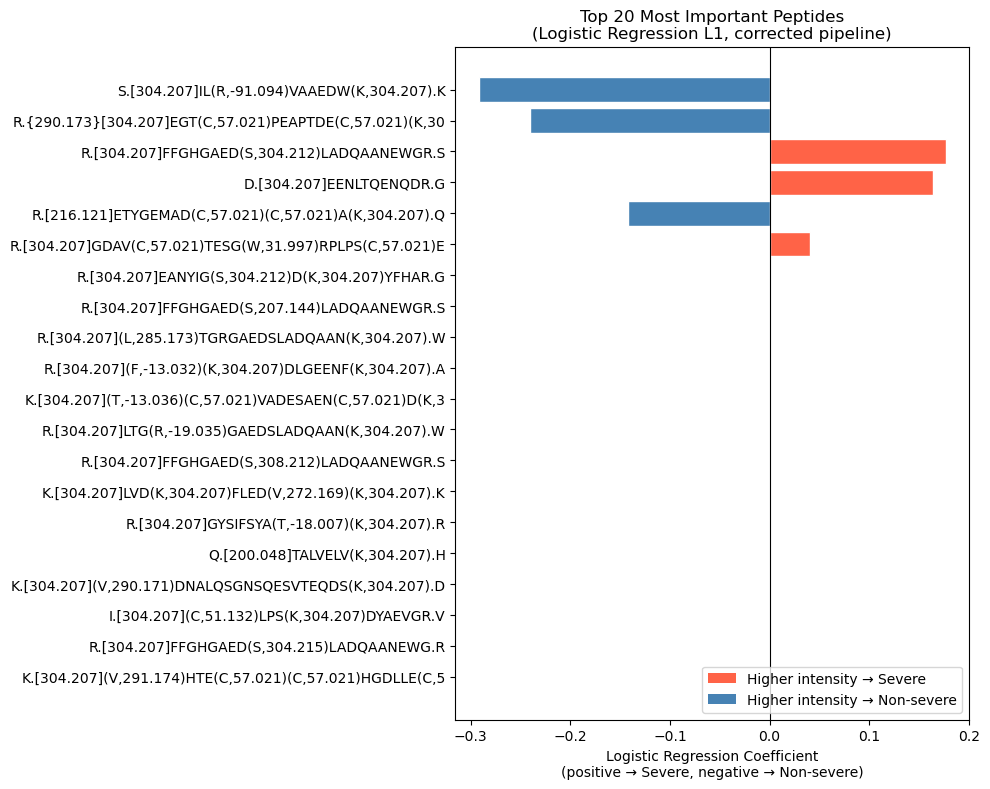

Chart saved as top20_peptide_importance.png


In [6]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20).copy()

# Shorten peptide names for readability on the chart
top20["label"] = top20["peptide"].str[:55]

colors = ["tomato" if c > 0 else "steelblue" for c in top20["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top20["label"], top20["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()  # most important peptide at the top

ax.set_xlabel("Logistic Regression Coefficient\n(positive → Severe, negative → Non-severe)")
ax.set_title("Top 20 Most Important Peptides\n(Logistic Regression L1, corrected pipeline)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato",    label="Higher intensity → Severe"),
    Patch(facecolor="steelblue", label="Higher intensity → Non-severe"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("top20_peptide_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as top20_peptide_importance.png")